# Three-Oscillator Coupled Lorenz Network — Chaotic Regime Search
## Equations of motion (per oscillator $i \in \{1,2,3\}$)
$$\dot{x}_i = \sigma(y_i - x_i)$$
$$\dot{y}_i = x_i(\rho_i - z_i) - y_i + \sum_{j \neq i} k_{ij}(y_j - y_i)$$
$$\dot{z}_i = x_i y_i - \beta z_i$$

Coupling acts on the $y$-equation (diffusive). State vector: $[x_1,y_1,z_1,x_2,y_2,z_2,x_3,y_3,z_3]$ **(9D)**.

**Poincaré section:** upward crossings of $z_i = \rho_i - 1$ per oscillator (geometric, no forcing frequency).

In [20]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 100000

from ExperimentTracker import ExperimentTracker
from time import time
from Logger import Logger
import ipynbname
import os

NOTEBOOK_NAME = ipynbname.name()
OP_DIR = os.path.abspath(os.path.join(os.path.curdir, "Outputs-3_Lorenz"))

from Helpers import read_json_config, time_format
PARAM_CONFIG_DIR = os.path.abspath(os.path.join(os.path.curdir, "3OscLorenzParams.config"))
PARAMS = read_json_config(PARAM_CONFIG_DIR)

os.makedirs(OP_DIR, exist_ok=True)
tracker = ExperimentTracker(OP_DIR)

LINE_WIDTH = 0.15
DPI = 750
DOT_RADIUS = 0.5
ASPECT_RATIO_INV = 1

In [21]:
def lorenz_3osc_coupled(t, state, params):
    x1, y1, z1, x2, y2, z2, x3, y3, z3 = state
    p = params
    s, b = p['sigma'], p['beta']
    r1, r2, r3 = p['rho1'], p['rho2'], p['rho3']
    k12, k13, k23 = p['k12'], p['k13'], p['k23']

    dx1 = s * (y1 - x1)
    dy1 = x1*(r1 - z1) - y1 + k12*(y2 - y1) + k13*(y3 - y1)
    dz1 = x1*y1 - b*z1

    dx2 = s * (y2 - x2)
    dy2 = x2*(r2 - z2) - y2 + k12*(y1 - y2) + k23*(y3 - y2)
    dz2 = x2*y2 - b*z2

    dx3 = s * (y3 - x3)
    dy3 = x3*(r3 - z3) - y3 + k13*(y1 - y3) + k23*(y2 - y3)
    dz3 = x3*y3 - b*z3

    return [dx1, dy1, dz1, dx2, dy2, dz2, dx3, dy3, dz3]

In [22]:
def simulate(params=None, x0=None, t_span=(0, 200), ts_per_sec=50, verbose=True):
    if params is None:
        params = PARAMS
    if x0 is None:
        x0 = [1.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.5, 0.0, 0.0]

    t_eval = np.arange(t_span[0], t_span[1], 1/ts_per_sec)
    start_time = time()

    sol = solve_ivp(
        fun=lambda t, y: lorenz_3osc_coupled(t, y, params),
        t_span=t_span,
        y0=x0,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-9,
        atol=1e-9,
        dense_output=False
    )

    duration = time() - start_time
    msg = ''
    if verbose:
        msg += f'Simulated {(t_span[1]-t_span[0])*ts_per_sec:.0f} steps for {len(x0)} states in [{time_format(duration)}].'
        msg += '\nParameters:'
        for key, value in params.items():
            msg += f'\n\t{key:20} {value}'
    return sol.t, sol.y, msg

def drop_transient(t, sol, frac=0.3):
    n = int(len(t) * frac)
    return t[n:], sol[:, n:]

def plot_phase_portrait(sol, title='Phase Portrait', save_path=None):
    global OP_DIR, NOTEBOOK_NAME
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, ax in enumerate(axes):
        ax.plot(sol[3*i], sol[3*i+1], lw=LINE_WIDTH, color='steelblue', alpha=0.8)
        ax.set_xlabel(f'$x_{i+1}$')
        ax.set_ylabel(f'$y_{i+1}$')
        ax.set_title(f'Oscillator {i+1}')
        ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    save_path = '' if save_path is None else save_path
    fig.savefig(os.path.join(save_path, f'{NOTEBOOK_NAME}_out_FP.png'), dpi=DPI)

def poincare_section(t, sol, params, transient_frac=0.3):
    '''
    Geometric Poincare section: upward crossings of z_i = rho_i - 1 per oscillator.
    Returns list of 3 tuples: [(x1_pts, y1_pts), (x2_pts, y2_pts), (x3_pts, y3_pts)]
    '''
    n_drop = int(len(t) * transient_frac)
    s = sol[:, n_drop:]
    rhos = [params['rho1'], params['rho2'], params['rho3']]
    sections = []
    for i in range(3):
        z = s[3*i + 2]
        x = s[3*i + 0]
        y = s[3*i + 1]
        z_thresh = rhos[i] - 1.0
        up = (z[:-1] < z_thresh) & (z[1:] >= z_thresh)
        idx = np.where(up)[0]
        sections.append((x[idx], y[idx]))
    return sections

def plot_poincare(sections, title='Poincare Section', save_path=None):
    global OP_DIR, NOTEBOOK_NAME
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, ax in enumerate(axes):
        xi, yi = sections[i]
        ax.scatter(xi, yi, s=DOT_RADIUS, color='crimson', alpha=0.7)
        ax.set_xlabel(f'$x_{i+1}$')
        ax.set_ylabel(f'$y_{i+1}$')
        ax.set_title(f'Oscillator {i+1}')
        ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    save_path = '' if save_path is None else save_path
    fig.savefig(os.path.join(save_path, f'{NOTEBOOK_NAME}_out_PS.png'), dpi=DPI)

In [23]:
def compute_mle(params, x0=None, t_span=(0, 200), ts_per_sec=50,
             eps=1e-8, renorm_interval=5, transient_frac=0.2, verbose=False):
    '''
    MLE via renormalization.
    renorm_interval=5 fits Lorenz timescales (standard MLE ~0.9).
    '''
    if x0 is None:
        x0 = [1.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.5, 0.0, 0.0]

    t_full, sol_full, _ = simulate(params=params, x0=x0,
                                   t_span=t_span, ts_per_sec=ts_per_sec,
                                   verbose=verbose)
    n_drop = int(len(t_full) * transient_frac)
    x_ref  = sol_full[:, n_drop]

    x_pert    = x_ref.copy()
    x_pert[0] += eps

    lyapunov_sum = 0.0
    n_renorm     = 0
    growth_log   = []
    t_current    = t_full[n_drop]

    while t_current < t_span[1]:
        t_end = min(t_current + renorm_interval, t_span[1])

        sol_ref = solve_ivp(
            fun=lambda t, y: lorenz_3osc_coupled(t, y, params),
            t_span=(t_current, t_end),
            y0=x_ref,
            method='RK45', rtol=1e-9, atol=1e-9,
            dense_output=False
        )
        sol_per = solve_ivp(
            fun=lambda t, y: lorenz_3osc_coupled(t, y, params),
            t_span=(t_current, t_end),
            y0=x_pert,
            method='RK45', rtol=1e-9, atol=1e-9,
            dense_output=False
        )

        x_ref  = sol_ref.y[:, -1]
        x_pert = sol_per.y[:, -1]

        delta      = x_pert - x_ref
        delta_norm = np.linalg.norm(delta)

        if delta_norm == 0:
            break

        lyapunov_sum += np.log(delta_norm / eps)
        n_renorm     += 1
        x_pert        = x_ref + eps * (delta / delta_norm)
        t_current     = t_end

        mle_running = lyapunov_sum / (n_renorm * renorm_interval)
        growth_log.append((t_current, mle_running))

    mle_final = lyapunov_sum / (n_renorm * renorm_interval) if n_renorm > 0 else 0.0
    return mle_final, np.array(growth_log)

def plot_mle_convergence(growth_log, mle_final, title='MLE Convergence', save_path=None):
    global OP_DIR, NOTEBOOK_NAME
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(growth_log[:, 0], growth_log[:, 1], lw=1.0, color='darkorange')
    ax.axhline(y=mle_final, color='crimson', lw=1.0, linestyle='--',
               label=f'MLE = {mle_final:.4f}')
    ax.axhline(y=0, color='gray', lw=0.8, linestyle=':')
    ax.set_xlabel('Time')
    ax.set_ylabel('Running MLE estimate')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    save_path = '' if save_path is None else save_path
    fig.savefig(os.path.join(save_path, f'{NOTEBOOK_NAME}_out_MLE.png'), dpi=300)

In [24]:
PARAMS

{'sigma': 10.0,
 'beta': 2.66666667,
 'rho1': 33.2599826,
 'rho2': 33.1928453,
 'rho3': 34.7871651,
 'k12': 4.01022515,
 'k13': 9.26259199,
 'k23': 1.51869548}

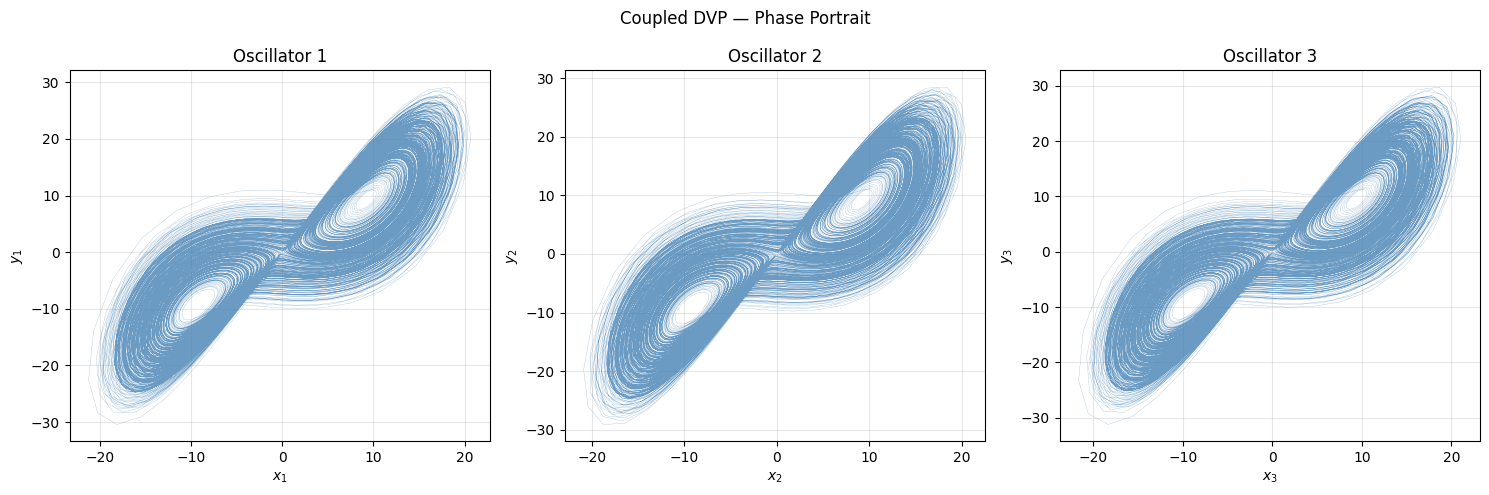

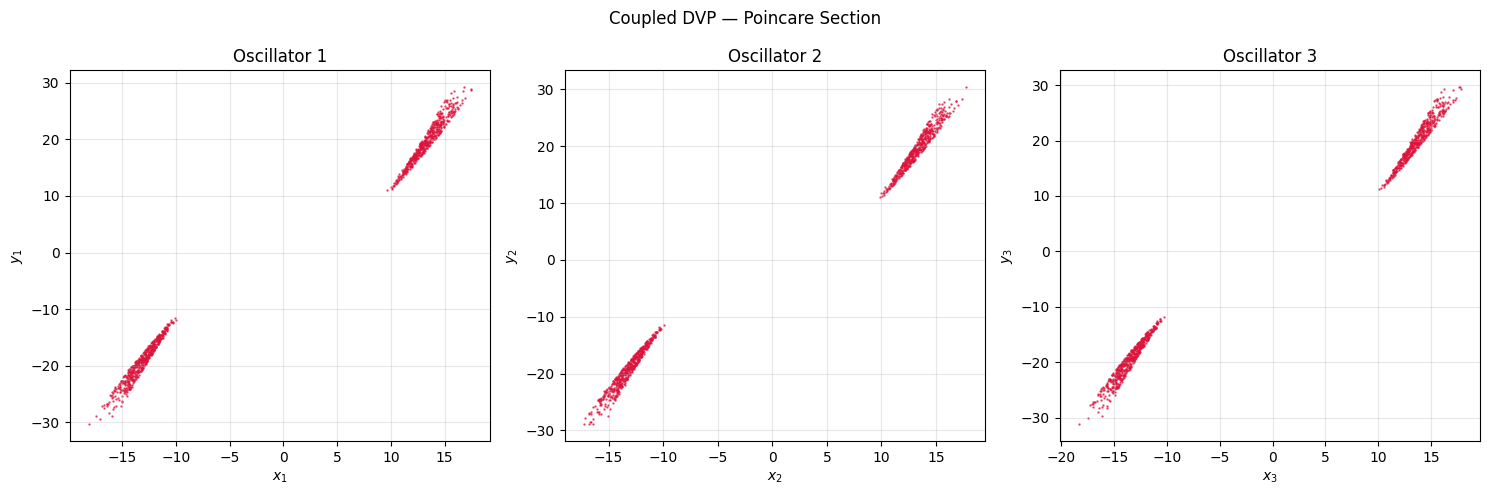

Logger initialized with file 2026-04-03_00-10-48_f4833a9ae6.log
[2026-04-03 00:11:24] [INFO] [DEF]: Simulated 50000 steps for 9 states in [0.0 hrs 0.0 mins 12.97 secs].
[2026-04-03 00:11:24] [INFO] [DEF]: Parameters:
[2026-04-03 00:11:24] [INFO] [DEF]: 	sigma                10.0
[2026-04-03 00:11:24] [INFO] [DEF]: 	beta                 2.66666667
[2026-04-03 00:11:24] [INFO] [DEF]: 	rho1                 33.2599826
[2026-04-03 00:11:24] [INFO] [DEF]: 	rho2                 33.1928453
[2026-04-03 00:11:24] [INFO] [DEF]: 	rho3                 34.7871651
[2026-04-03 00:11:24] [INFO] [DEF]: 	k12                  4.01022515
[2026-04-03 00:11:24] [INFO] [DEF]: 	k13                  9.26259199
[2026-04-03 00:11:24] [INFO] [DEF]: 	k23                  1.51869548
[2026-04-03 00:11:24] [INFO] [DEF]: 	t_start              0
[2026-04-03 00:11:24] [INFO] [DEF]: 	t_end                1000
[2026-04-03 00:11:24] [INFO] [DEF]: 	transient_drop_frac  0.5
[2026-04-03 00:11:24] [INFO] [DEF]: MLE = 1.0354


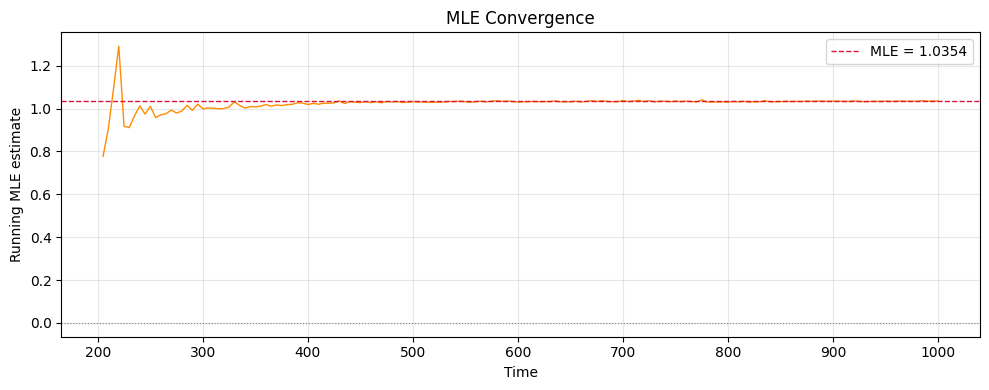

In [25]:
PARAMS.update({
    "t_start":0,
    "t_end":1000,
    "transient_drop_frac" : 0.5,
})
t, sol, msg = simulate(t_span=[PARAMS['t_start'],PARAMS['t_end']])
t_trim, sol_trim = drop_transient(t, sol, frac=PARAMS['transient_drop_frac'])
ps = poincare_section(t, sol, PARAMS)

run = tracker.create_run(params=PARAMS, notes="SIM: trying largest obtained MLE value from 2026-04-02_17-28-52_57bd987568")

plot_phase_portrait(sol_trim, title="Coupled DVP — Phase Portrait", save_path=run.get_path("logs"))
plot_poincare(ps, title="Coupled DVP — Poincare Section", save_path=run.get_path("logs"))

run.copy_file("3OscLorenzParams.config", "")

mle, growth_log = compute_mle(PARAMS, t_span=[PARAMS['t_start'],PARAMS['t_end']])
logger = Logger(os.path.join(run.get_path("logs"), f"{run.uid}.log"))
logger.start_session()
logger(msg)
logger(f"MLE = {mle:.4f}")
plot_mle_convergence(growth_log, mle, save_path=run.get_path("logs"))
logger.end_session()

In [30]:
sol_trim[:,0]

array([-1.60519921, -2.57200496, 17.75313115, -1.581399  , -2.50262911,
       17.73782027, -1.69841396, -2.69272697, 18.35884089])

### Sweeping parameter space — targeting MLE > 0.2
Coupling modes:
- `independent`: 6D LHS over $[\rho_1, \rho_2, \rho_3, k_{12}, k_{13}, k_{23}]$. Fixed: $\sigma=10$, $\beta=8/3$.
- `common`: 4D LHS over $[\rho_1, \rho_2, \rho_3, k]$ (single coupling for all pairs). Fixed: $\sigma=10$, $\beta=8/3$.

Lorenz chaos appears when $\rho_i > 24.74$. Below this the system has stable equilibria.

In [17]:
from scipy.stats import qmc
from joblib import Parallel, delayed

def mle_for_params(param_sample, coupling_mode='independent'):
    if coupling_mode == 'independent':
        rho1, rho2, rho3, k12, k13, k23 = param_sample
    else:
        rho1, rho2, rho3, k = param_sample
        k12, k13, k23 = k, k, k

    params = {
        'sigma': 10.0,
        'beta':  8.0/3.0,
        'rho1':  rho1, 'rho2': rho2, 'rho3': rho3,
        'k12':   k12,  'k13':  k13,  'k23':  k23,
    }

    try:
        mle, _ = compute_mle(params, t_span=(0, 200), ts_per_sec=50)
        if coupling_mode == 'independent':
            return (rho1, rho2, rho3, k12, k13, k23, mle)
        else:
            return (rho1, rho2, rho3, k, mle)
    except Exception as e:
        print(f'Failed: {e}')
        if coupling_mode == 'independent':
            return (rho1, rho2, rho3, k12, k13, k23, np.nan)
        else:
            return (rho1, rho2, rho3, k, np.nan)

def sweep_mle_lhs(sweep_params, n_samples=10000, n_jobs=-1, seed=42, coupling_mode='independent'):
    # ---- SEARCH SPACE ----
    # coupling_mode='independent': 6D LHS [rho1, rho2, rho3, k12, k13, k23]
    #   rho in [20, 35]: spans pre-chaotic (<24.74) and strongly chaotic (>24.74)
    #   k   in [0, 5]:   uncoupled → strong coupling (synchronization regime)
    # coupling_mode='common': 4D LHS [rho1, rho2, rho3, k]
    bounds_low  = sweep_params['bounds_low']
    bounds_high = sweep_params['bounds_high']
    d = len(bounds_low)

    sampler = qmc.LatinHypercube(d=d, seed=seed)
    sample  = sampler.random(n=n_samples)
    samples = qmc.scale(sample, bounds_low, bounds_high)

    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(mle_for_params)(s, coupling_mode) for s in samples
    )
    return np.array(results)

In [ ]:
# # ---- SEARCH SPACE (6D: independent coupling) ----
# # Swept : rho1, rho2, rho3 in [20, 35]   |  k12, k13, k23 in [0, 5]
# # Fixed : sigma=10, beta=8/3

# COUPLING_MODE = 'independent'   # 'independent' or 'common'

# sweep_params = {
#     'mle_threshold': 0.2,
#     'n_samples':     5000,
#     'seed':          42,
#     'bounds_low':    [20.0, 20.0, 20.0, 0.0, 0.0, 0.0],
#     'bounds_high':   [35.0, 35.0, 35.0, 5.0, 5.0, 5.0]
# }

# # For common coupling mode, swap to 4D bounds:
# # sweep_params = {
# #     'mle_threshold': 0.2,
# #     'n_samples':     10000,
# #     'seed':          42,
# #     'bounds_low':    [20.0, 20.0, 20.0, 0.0],
# #     'bounds_high':   [35.0, 35.0, 35.0, 5.0]
# # }

# run    = tracker.create_run(
#     sweep_params,
#     f"3OscLorenz {int(sweep_params['n_samples']/1000)}k-LHS MLE sweep ({COUPLING_MODE}), threshold={sweep_params['mle_threshold']}"
# )
# logger = Logger(os.path.join(run.get_path('logs'), f'{run.uid}.log'))
# logger.start_session()
# logger(f'Coupling mode: {COUPLING_MODE}')
# logger(f"Sweeping {len(sweep_params['bounds_low'])}D parameter space, n_samples={sweep_params['n_samples']}")

# results = sweep_mle_lhs(sweep_params, n_samples=sweep_params['n_samples'],
#                         seed=sweep_params['seed'], coupling_mode=COUPLING_MODE)

# threshold = sweep_params['mle_threshold']
# chaotic   = results[results[:, -1] > threshold]

# mle_col = results[:, -1]
# valid   = mle_col[~np.isnan(mle_col)]
# logger(f'MLE stats: max={np.max(valid):.4f}, mean={np.mean(valid):.4f}, std={np.std(valid):.4f}')
# logger(f'Positive MLE count: {np.sum(valid > 0)} / {len(valid)}')
# logger(f'MLE > 0.05: {np.sum(valid > 0.05)}, MLE > 0.1: {np.sum(valid > 0.1)}, MLE > 0.2: {np.sum(valid > 0.2)}')
# logger(f'Found {len(chaotic)} chaotic parameter sets above MLE={threshold}')
# logger('Top 20 sorted descending by MLE:')
# logger(str(chaotic[chaotic[:, -1].argsort()[::-1]][:20]))
# mle_store_path = f"MLE_above_0_1.pkl"
# logger(f"Storing mle values in {mle_store_path}")
# mle_store_path = os.path.join(f"{run.get_path('data') }",mle_store_path)
# run.save_binary(mle_store_path, results[results[:,-1] > 0.1])
# logger.end_session()

Logger initialized with file 2026-04-02_17-28-52_57bd987568.log
[2026-04-02 17:28:52] [INFO] [DEF]: Coupling mode: independent
[2026-04-02 17:28:52] [INFO] [DEF]: Sweeping 6D parameter space, n_samples=5000


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   33.0s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done 850 tasks      | elapsed:  9.2min
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed: 12.3min
[Parallel(n_jobs=-1)]: Done 1426 tasks      | elapsed: 15.8min
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed: 20.0min
[Parallel(n_jobs=-1)]: Done 2146 tasks      | elapsed: 24.1min
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed: 28.9min
[Parallel(n_jobs=-1)]: Done 3010 tasks      | elapsed: 33.8min
[Parallel(n_jobs=-1)]: Done 3496 tasks      | elapsed: 39.1min
[Parallel(n_jobs=-1)]: Done 4018 tasks      | elapsed: 44.6min
[Parallel(n_jobs=-1)]: Done 4576 tasks      | e

[2026-04-02 18:23:48] [INFO] [DEF]: MLE stats: max=1.2237, mean=0.5251, std=0.4492
[2026-04-02 18:23:48] [INFO] [DEF]: Positive MLE count: 3446 / 5000
[2026-04-02 18:23:48] [INFO] [DEF]: MLE > 0.05: 3321, MLE > 0.1: 3274, MLE > 0.2: 3195
[2026-04-02 18:23:48] [INFO] [DEF]: Found 3195 chaotic parameter sets above MLE=0.2
[2026-04-02 18:23:48] [INFO] [DEF]: Top 20 sorted descending by MLE:
[2026-04-02 18:23:48] [INFO] [DEF]: [[3.32599826e+01 3.31928453e+01 3.47871651e+01 4.01022515e+00
[2026-04-02 18:23:48] [INFO] [DEF]:   9.26259199e-01 1.51869548e+00 1.22368734e+00]
[2026-04-02 18:23:48] [INFO] [DEF]:  [3.39544291e+01 3.41606186e+01 3.36040993e+01 1.88798093e-01
[2026-04-02 18:23:48] [INFO] [DEF]:   3.76492660e-02 1.72858995e+00 1.21342941e+00]
[2026-04-02 18:23:48] [INFO] [DEF]:  [3.46532874e+01 2.64753018e+01 3.41374678e+01 5.71941934e-01
[2026-04-02 18:23:48] [INFO] [DEF]:   2.36428741e+00 3.70268729e-01 1.19710891e+00]
[2026-04-02 18:23:48] [INFO] [DEF]:  [2.95106043e+01 3.35203236

[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 54.9min finished


In [19]:
mle_store_path = f"MLE_above_0_1.pkl"

mle_store_path = os.path.join(f"{run.get_path('data') }",mle_store_path)
mle_store_path

'd:\\Repos\\Augmented-Attractor-Shaping-For-Nonlinear-Feedback-Systems\\Take 2\\Pillar 2\\Outputs-3_Lorenz\\2026-04-02_17-28-52_57bd987568\\data\\MLE_above_0_1.pkl'

In [1]:
# import numpy as np
# from scipy.integrate import solve_ivp
# import matplotlib.pyplot as plt

# # Lorenz system
# def lorenz(t, state, sigma=10, rho=28, beta=8/3):
#     x, y, z = state
#     dx = sigma * (y - x)
#     dy = x * (rho - z) - y
#     dz = x * y - beta * z
#     return [dx, dy, dz]

# # Time span
# t_span = (0, 40)
# t_eval = np.linspace(*t_span, 10000)

# # Initial condition
# y0 = [1.0, 1.0, 1.0]

# # Solve ODE
# sol = solve_ivp(lorenz, t_span, y0, t_eval=t_eval)

# # Plot
# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(projection='3d')

# ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.7)
# ax.set_title("Lorenz Attractor")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()

In [2]:
# import numpy as np
# from scipy.integrate import solve_ivp
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation

# # Lorenz system
# def lorenz(t, state, sigma=10, rho=28, beta=8/3):
#     x, y, z = state
#     return [
#         sigma * (y - x),
#         x * (rho - z) - y,
#         x * y - beta * z
#     ]

# # Solve system
# t_span = (0, 40)
# t_eval = np.linspace(*t_span, 1000)
# y0 = [1.0, 1.0, 1.0]

# sol = solve_ivp(lorenz, t_span, y0, t_eval=t_eval)
# x, y, z = sol.y

# # Set up figure
# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(projection='3d')

# line, = ax.plot([], [], [], lw=1)
# point, = ax.plot([], [], [], 'ro', markersize=4)

# ax.set_xlim((min(x), max(x)))
# ax.set_ylim((min(y), max(y)))
# ax.set_zlim((min(z), max(z)))

# ax.set_title("Lorenz Attractor Animation")

# # Animation update function
# trail = 100  # number of points in trail

# def update(frame):
#     start = max(0, frame - trail)
    
#     line.set_data(x[start:frame], y[start:frame])
#     line.set_3d_properties(z[start:frame])
    
#     point.set_data([x[frame]], [y[frame]])
#     point.set_3d_properties([z[frame]])
    
#     return line, point

# # Create animation
# ani = FuncAnimation(fig, update,
#                     frames=len(t_eval),
#                     interval=10,
#                     blit=False)

# # plt.show()
# ani.save("lorenz.mp4", writer="ffmpeg", fps=30)


For fluid real-time interaction, switch to:

Plotly -> browser-based, smoother

PyVista -> GPU-backed

or even VPython